# Data

In [210]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import nltk
import streamlit as st
import plotly.express as px
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.stem import WordNetLemmatizer
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords
from string import punctuation
from google_play_scraper import Sort, reviews_all
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [42]:
result = reviews_all(
    'com.ubercab',
    sleep_milliseconds=0,
    lang='eng',
    country ='uk',
    sort = Sort.NEWEST,
    filter_score_with=None
)

In [148]:
df = pd.DataFrame(np.array(result), columns=['review'])
df = df.join(pd.DataFrame(df.pop('review').tolist()))
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,a9f3cacf-4a3b-42e1-82cb-a6cf288c7123,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,everything has been done well!,5,0,4.573.10001,2025-04-13 18:48:34,None,NaT,4.573.10001
1,ed38d11b-cf1a-42bf-8d81-f54c5c6e52cf,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,he was very helpful he assisted me with the kids and my bags,5,0,4.573.10001,2025-04-13 18:47:12,None,NaT,4.573.10001
2,844d00ed-0652-4880-bef2-5f8027e8b4e6,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"on time , driver is cool",5,0,4.572.10005,2025-04-13 18:46:21,None,NaT,4.572.10005
3,07d0de48-813d-45d7-bbad-0e583c9c833d,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Trip fare cahanged and increased by 40% when we reached at destination, Very bad idea of Uber to fool the customers.",1,0,4.573.10001,2025-04-13 18:46:12,None,NaT,4.573.10001
4,f70d67bd-af5a-4605-9549-ae303bbf0b34,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,good,5,0,4.573.10001,2025-04-13 18:44:44,None,NaT,4.573.10001
...,...,...,...,...,...,...,...,...,...,...,...
269995,b0f22b6c-a95f-4393-869c-b3488117e70d,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,Nice,5,0,4.500.10002,2023-11-17 00:17:52,None,NaT,4.500.10002
269996,b498b2d8-baa8-42d6-b7c4-870556ef457c,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,Fare Change in every time,4,0,4.500.10002,2023-11-17 00:14:16,None,NaT,4.500.10002
269997,4dcaccd4-c67f-4fcd-9f22-afbb054bfdf0,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"I'm always using apps there is no problem, exilent service, Thanks a lat for all itare team.",5,0,None,2023-11-17 00:10:55,None,NaT,None
269998,e63ae2d6-ec0c-4ab9-bbf5-8033ce7cd68b,A Google user,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,I've always had a great experience. Friendly courteous drivers.,5,0,4.476.10002,2023-11-17 00:08:11,None,NaT,4.476.10002


In [149]:
data=df[['content', 'score', 'at']]

In [150]:
data.to_csv('uber_reviews.csv', index=False)

In [151]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   content  270000 non-null  object        
 1   score    270000 non-null  int64         
 2   at       270000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 6.2+ MB


In [152]:
data = pd.read_csv('uber_reviews.csv')
data

,content,score,at
0,everything has been done well!,5,2025-04-13 18:48:34
1,he was very helpful he assisted me with the kids and my bags,5,2025-04-13 18:47:12
2,"on time , driver is cool",5,2025-04-13 18:46:21
3,"Trip fare cahanged and increased by 40% when we reached at destination, Very bad idea of Uber to fool the customers.",1,2025-04-13 18:46:12
4,good,5,2025-04-13 18:44:44
...,...,...,...
269995,Nice,5,2023-11-17 00:17:52
269996,Fare Change in every time,4,2023-11-17 00:14:16
269997,"I'm always using apps there is no problem, exilent service, Thanks a lat for all itare team.",5,2023-11-17 00:10:55
269998,I've always had a great experience. Friendly courteous drivers.,5,2023-11-17 00:08:11


In [153]:
missing_values = data[['content','score', 'at']].isnull().sum()
print(missing_values)

content    18
score       0
at          0
dtype: int64


In [154]:
# Hapus baris dengan missing value di kolom 'content'
data = data.dropna(subset=['content'])

# Text Preprocessing 1

> ## Converting to lower case

In [155]:
def to_lower(text):
    return text.lower()

> ## Contraction

In [156]:
contractions_dict = {
"ain't": "am not",
"aren't": "are not",
"can't": "cannot",
"can't've": "cannot have",
"'cause": "because",
"could've": "could have",
"couldn't": "could not",
"couldn't've": "could not have",
"didn't": "did not",
"doesn't": "does not",
"don't": "do not",
"hadn't": "had not",
"hadn't've": "had not have",
"hasn't": "has not",
"haven't": "have not",
"he'd": "he had",
"he'd've": "he would have",
"he'll": "he will",
"he'll've": "he will have",
"he's": "he is",
"how'd": "how did",
"how'd'y": "how do you",
"how'll": "how will",
"how's": "how is",
"I'd": "I had",
"I'd've": "I would have",
"I'll": "I will",
"I'll've": "I will have",
"I'm": "I am",
"I've": "I have",
"isn't": "is not",
"it'd": "it had",
"it'd've": "it would have",
"it'll": "it will",
"it'll've": "iit will have",
"it's": "it is",
"let's": "let us",
"ma'am": "madam",
"mayn't": "may not",
"might've": "might have",
"mightn't": "might not",
"mightn't've": "might not have",
"must've": "must have",
"mustn't": "must not",
"mustn't've": "must not have",
"needn't": "need not",
"needn't've": "need not have",
"o'clock": "of the clock",
"oughtn't": "ought not",
"oughtn't've": "ought not have",
"shan't": "shall not",
"sha'n't": "shall not",
"shan't've": "shall not have",
"she'd": "she had",
"she'd've": "she would have",
"she'll": "she will",
"she'll've": "she will have",
"she's": "she is",
"should've": "should have",
"shouldn't": "should not",
"shouldn't've": "should not have",
"so've": "so have",
"so's": "so is",
"that'd": "that had",
"that'd've": "that would have",
"that's": "that is",
"there'd": "there had",
"there'd've": "there would have",
"there's": "there is",
"they'd": "they had",
"they'd've": "they would have",
"they'll": "they will",
"they'll've": "they will have",
"they're": "they are",
"they've": "they have",
"to've": "to have",
"wasn't": "was not",
"we'd": "we had",
"we'd've": "we would have",
"we'll": "we will",
"we'll've": "we will have",
"we're": "we are",
"we've": "we have",
"weren't": "were not",
"what'll": "what will",
"what'll've": "what will have",
"what're": "what are",
"what's": "what is",
"what've": "what have",
"when's": "when is",
"when've": "when have",
"where'd": "where did",
"where's": "where is",
"where've": "where have",
"who'll": "who will",
"who'll've": "who will have",
"who's": "who is",
"who've": "who have",
"why's": "why is",
"why've": "why have",
"will've": "will have",
"won't": "will not",
"won't've": "will not have",
"would've": "would have",
"wouldn't": "would not",
"wouldn't've": "would not have",
"y'all": "you all",
"y'all'd": "you all would",
"y'all'd've": "you all would have",
"y'all're": "you all are",
"y'all've": "you all have",
"you'd": "you had",
"you'd've": "you would have",
"you'll": "you will",
"you'll've": "you will have",
"you're": "you are",
"you've": "you have"
}

def expand_contractions(text, contractions_dict):
    contractions_pattern = re.compile('({})'.format('|'.join(contractions_dict.keys())),
                                      flags=re.IGNORECASE | re.DOTALL)

    def expand_match(contraction):
        match = contraction.group(0)
        first_char = match[0]
        expanded_contraction = contractions_dict.get(match) \
            if contractions_dict.get(match) \
            else contractions_dict.get(match.lower())
        expanded_contraction = expanded_contraction
        return expanded_contraction

    expanded_text = contractions_pattern.sub(expand_match, text)
    expanded_text = re.sub("'", "", expanded_text)
    return expanded_text

def main_contraction(text):
    text = expand_contractions(text, contractions_dict)
    return text

> ## Remove or Convert Number Into Text

In [157]:
def remove_numbers(text):
    output = ''.join(c for c in text if not c.isdigit())
    return output

> ## Remove Punctuation

In [158]:
def remove_punct(text):
    return ''.join(c for c in text if c not in punctuation)

> ## Remove White Spaces

In [159]:
def to_strip(text):
    return " ".join(text.split())

> ## Remove Stop Words and Particular Words

In [160]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rinda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rinda\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rinda\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [161]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [162]:
def remove_stopwords(sentence):
    stop_words = stopwords.words('english')
    return ' '.join([w for w in nltk.word_tokenize(sentence) if not w in stop_words])

> ## Combine Preprocessing Method

In [163]:
pd.options.display.max_colwidth = None

In [164]:
data['review1'] = data['content'].apply(to_lower)
data['review2'] = data['review1'].apply(main_contraction)
data['review3'] = data['review2'].apply(remove_numbers)
data['review4'] = data['review3'].apply(remove_punct)
data['review5'] = data['review4'].apply(to_strip)
data['review6'] = data['review5'].apply(remove_stopwords)
data

C:\Users\rinda\AppData\Local\Temp\ipykernel_27052\4146826270.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['review1'] = data['content'].apply(to_lower)


C:\Users\rinda\AppData\Local\Temp\ipykernel_27052\4146826270.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['review2'] = data['review1'].apply(main_contraction)
C:\Users\rinda\AppData\Local\Temp\ipykernel_27052\4146826270.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['review3'] = data['review2'].apply(remove_numbers)
C:\Users\rinda\AppData\Local\Temp\ipykernel_27052\4146826270.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

,content,score,at,review1,review2,review3,review4,review5,review6
0,everything has been done well!,5,2025-04-13 18:48:34,everything has been done well!,everything has been done well!,everything has been done well!,everything has been done well,everything has been done well,everything done well
1,he was very helpful he assisted me with the kids and my bags,5,2025-04-13 18:47:12,he was very helpful he assisted me with the kids and my bags,he was very helpful he assisted me with the kids and my bags,he was very helpful he assisted me with the kids and my bags,he was very helpful he assisted me with the kids and my bags,he was very helpful he assisted me with the kids and my bags,helpful assisted kids bags
2,"on time , driver is cool",5,2025-04-13 18:46:21,"on time , driver is cool","on time , driver is cool","on time , driver is cool",on time driver is cool,on time driver is cool,time driver cool
3,"Trip fare cahanged and increased by 40% when we reached at destination, Very bad idea of Uber to fool the customers.",1,2025-04-13 18:46:12,"trip fare cahanged and increased by 40% when we reached at destination, very bad idea of uber to fool the customers.","trip fare cahanged and increased by 40% when we reached at destination, very bad idea of uber to fool the customers.","trip fare cahanged and increased by % when we reached at destination, very bad idea of uber to fool the customers.",trip fare cahanged and increased by when we reached at destination very bad idea of uber to fool the customers,trip fare cahanged and increased by when we reached at destination very bad idea of uber to fool the customers,trip fare cahanged increased reached destination bad idea uber fool customers
4,good,5,2025-04-13 18:44:44,good,good,good,good,good,good
...,...,...,...,...,...,...,...,...,...
269995,Nice,5,2023-11-17 00:17:52,nice,nice,nice,nice,nice,nice
269996,Fare Change in every time,4,2023-11-17 00:14:16,fare change in every time,fare change in every time,fare change in every time,fare change in every time,fare change in every time,fare change every time
269997,"I'm always using apps there is no problem, exilent service, Thanks a lat for all itare team.",5,2023-11-17 00:10:55,"i'm always using apps there is no problem, exilent service, thanks a lat for all itare team.","always using apps there is no problem, exilent service, thanks a lat for all itare team.","always using apps there is no problem, exilent service, thanks a lat for all itare team.",always using apps there is no problem exilent service thanks a lat for all itare team,always using apps there is no problem exilent service thanks a lat for all itare team,always using apps problem exilent service thanks lat itare team
269998,I've always had a great experience. Friendly courteous drivers.,5,2023-11-17 00:08:11,i've always had a great experience. friendly courteous drivers.,always had a great experience. friendly courteous drivers.,always had a great experience. friendly courteous drivers.,always had a great experience friendly courteous drivers,always had a great experience friendly courteous drivers,always great experience friendly courteous drivers


# Text Preprocessing 2

> ## Stemming

In [165]:
snowball_stemmer = SnowballStemmer('english')

def stem(text):
    """
    :param word_tokens:
    :return: list of words
    """
    stemmed_word = [snowball_stemmer.stem(word) for sent in nltk.sent_tokenize(text)for word in nltk.word_tokenize(sent)]
    return " ".join(stemmed_word)

> ## Lemmatization

In [166]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rinda\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [167]:
wordnet_lemmatizer = WordNetLemmatizer()

In [168]:
def lemmatize(text):
    lemmatized_word = [wordnet_lemmatizer.lemmatize(word)for sent in nltk.sent_tokenize(text)for word in nltk.word_tokenize(sent)]
    return " ".join(lemmatized_word)

> ## Apply Stemming or Lemmatization

In [169]:
data['message_prep_stem'] = data['review6'].apply(stem)
data['message_prep_lemma'] = data['review6'].apply(lemmatize)
data[['message_prep_stem','message_prep_lemma']]

C:\Users\rinda\AppData\Local\Temp\ipykernel_27052\284386481.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['message_prep_stem'] = data['review6'].apply(stem)
C:\Users\rinda\AppData\Local\Temp\ipykernel_27052\284386481.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['message_prep_lemma'] = data['review6'].apply(lemmatize)


,message_prep_stem,message_prep_lemma
0,everyth done well,everything done well
1,help assist kid bag,helpful assisted kid bag
2,time driver cool,time driver cool
3,trip fare cahang increas reach destin bad idea uber fool custom,trip fare cahanged increased reached destination bad idea uber fool customer
4,good,good
...,...,...
269995,nice,nice
269996,fare chang everi time,fare change every time
269997,alway use app problem exil servic thank lat itar team,always using apps problem exilent service thanks lat itare team
269998,alway great experi friend courteous driver,always great experience friendly courteous driver


# Text Exploration

> ## Word Freq

In [170]:
def kamus(check):
    check = check.str.extractall('([a-zA_Z]+)')
    check.columns = ['check']
    b = check.reset_index(drop=True)
    check = b['check'].value_counts()

    kamus = {'kata':check.index,'freq':check.values}
    kamus = pd.DataFrame(kamus)
    kamus.index = kamus['kata']
    kamus.drop('kata', axis = 1, inplace = True)
    kamus.sort_values('freq',ascending=False,inplace=True)

    return kamus

In [171]:
kamus_unclean = kamus(data['message_prep_lemma'])

<Axes: ylabel='kata'>

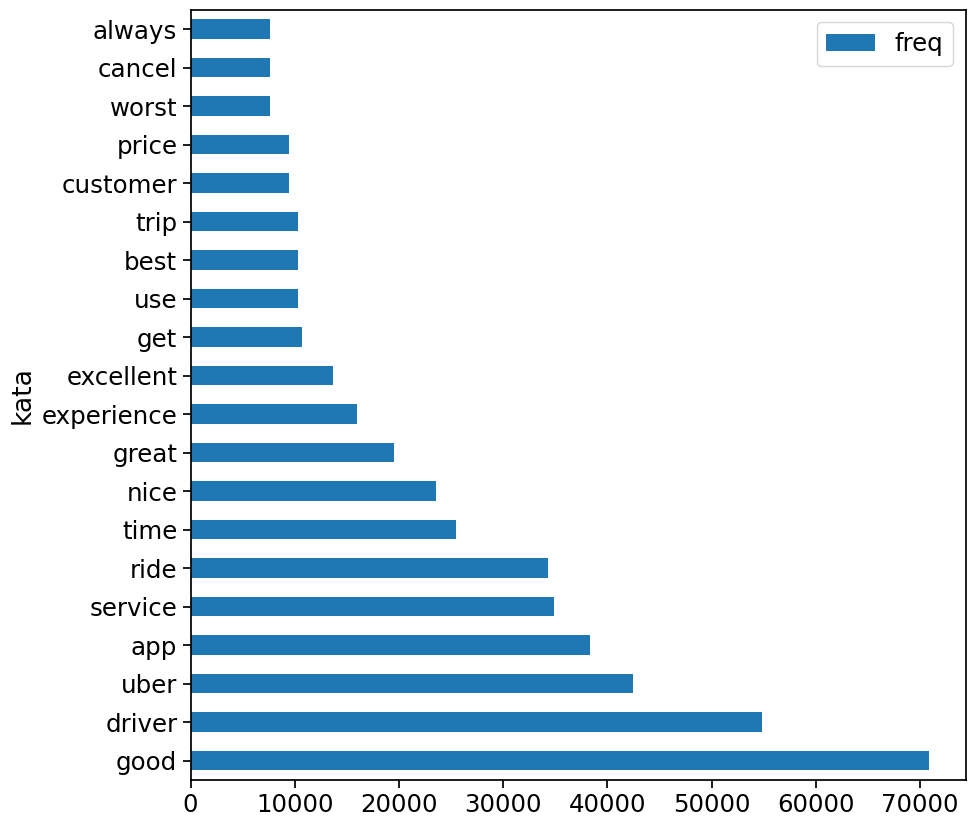

In [172]:
sns.set_context(context = 'notebook', font_scale = 1.6)
kamus_unclean[:20].plot(kind = 'barh',figsize = (10,10))

> ## Word Cloud

In [173]:
def plot_cloud(wordcloud):
    # Set figure size
    plt.figure(figsize=(20, 10))
    # Display image
    plt.imshow(wordcloud)
    # No axis details
    plt.axis("off")

In [174]:
word_cloud = WordCloud().generate(str(data['message_prep_lemma']))

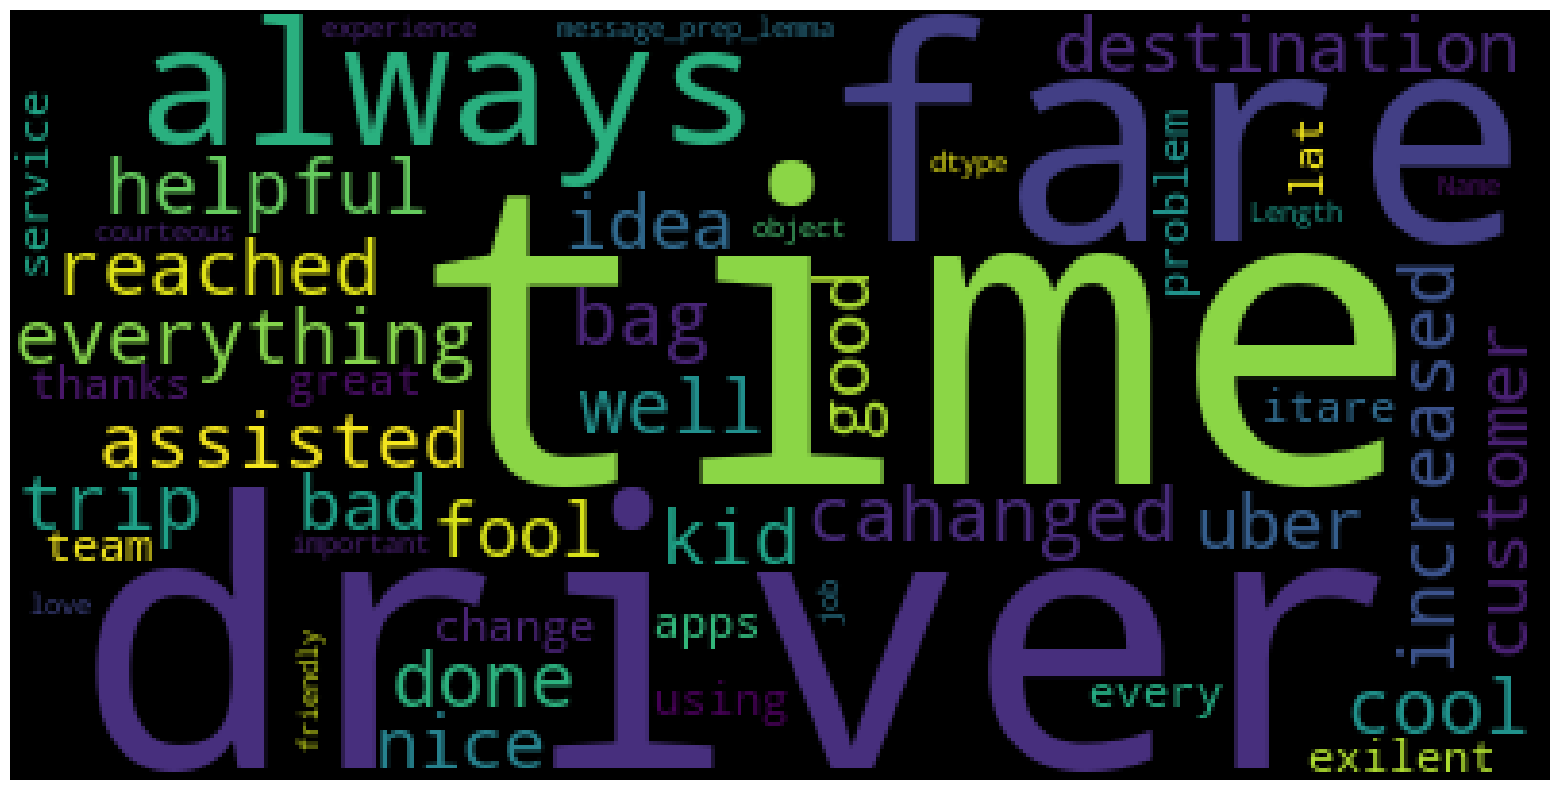

In [175]:
plot_cloud(word_cloud)

> # Distribusi Sentimen

In [176]:
# Klasifikasi sentimen berdasarkan skor
def classify_sentiment(score):
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

In [177]:
# Buat kolom baru 'sentiment'
data['sentiment'] = data['score'].apply(classify_sentiment)

# Hitung distribusi sentimen
sentiment_counts = data['sentiment'].value_counts().sort_index()

C:\Users\rinda\AppData\Local\Temp\ipykernel_27052\4202709396.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['sentiment'] = data['score'].apply(classify_sentiment)


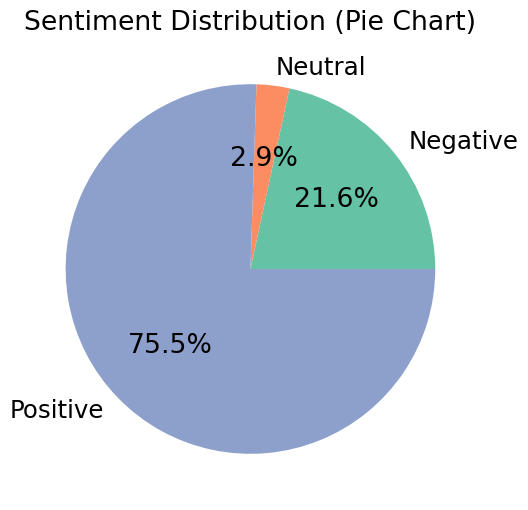

In [178]:
# Pie chart
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title("Sentiment Distribution (Pie Chart)")
plt.show()

Pie Chart menunjukkan proporsi persentase dalam masing-masing kategori:  
* Positive (skor 4–5)
* Neutral (skor 3)
* Negative (skor 1–2)

> # Analisis Sentimen vs Skor

In [179]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\rinda\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [180]:
sia = SentimentIntensityAnalyzer()

1. Analisis Sentimen dari Isi Review (VADER) vs Skor

In [181]:
# Hitung skor sentimen dari review (kolom bersih)
data['vader_compound'] = data['review6'].astype(str).apply(lambda x: sia.polarity_scores(x)['compound'])

# Klasifikasikan sentimen berdasarkan nilai compound
def get_sentiment(compound):
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

data['text_sentiment'] = data['vader_compound'].apply(get_sentiment)

C:\Users\rinda\AppData\Local\Temp\ipykernel_27052\1050915082.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['vader_compound'] = data['review6'].astype(str).apply(lambda x: sia.polarity_scores(x)['compound'])
C:\Users\rinda\AppData\Local\Temp\ipykernel_27052\1050915082.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['text_sentiment'] = data['vader_compound'].apply(get_sentiment)


2. Bandingkan Sentimen dari Skor vs Teks

In [182]:
# Contingency table: skor vs sentimen teks
comparison = pd.crosstab(data['score'], data['text_sentiment'])
comparison

text_sentiment,Negative,Neutral,Positive
score,,,
1,28721,11595,11214
2,2928,1639,2255
3,1975,2071,3693
4,1187,2884,14000
5,2041,23114,160665


3. Analisis Ketidaksesuaian (Mismatch)

In [183]:
# Cek kasus di mana skor positif tapi teks negatif
mismatch = data[(data['score'] >= 4) & (data['text_sentiment'] == 'Negative')]
mismatch[['score', 'content', 'review6', 'text_sentiment']]

,score,content,review6,text_sentiment
90,4,"I would have given 5 stars to this app, but a few of my concerns had been neglected by them. Most of the time, drivers (mostly Moto) would ask for higher fare even if the tip had already been added to the initial fare. No action would be taken even if a complaint was made to Uber.",would given stars app concerns neglected time drivers mostly moto would ask higher fare even tip already added initial fare action would taken even complaint made uber,Negative
322,5,we had put the stops in the wrong way round but the driver was helpful and followed our directions,put stops wrong way round driver helpful followed directions,Negative
336,5,except for driver is 7 min away then when I book it it 20 min before they come. very deceiving,except driver min away book min come deceiving,Negative
354,5,No problems getting picked up or dropped off!!!,problems getting picked dropped,Negative
593,5,service bahut acchi hoti hai extra charges kyon lagte,service bahut acchi hoti hai extra charges kyon lagte,Negative
...,...,...,...,...
269785,5,This trip is very comfortable but previous journey very bad rxperiens,trip comfortable previous journey bad rxperiens,Negative
269870,5,Nice and forced,nice forced,Negative
269892,5,No Complaints,complaints,Negative
269937,5,Medhai waited patiently for me. The ride was smooth and uneventful. Sorry if I spelled his name wrong.,medhai waited patiently ride smooth uneventful sorry spelled name wrong,Negative


> # Wordcloud per Sentimen (positif vs negatif)

Text(0.5, 1.0, 'WordCloud - Positive Reviews')

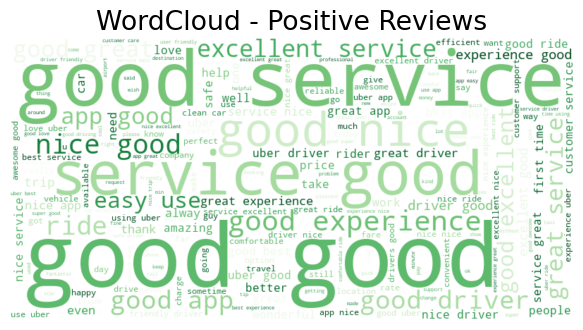

In [184]:
# Filter review berdasarkan sentimen dari isi teks (text_sentiment)
positive_text = " ".join(data[data['text_sentiment'] == 'Positive']['review6'].dropna())

# # Buat WordCloud untuk sentimen positif
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Positive Reviews')


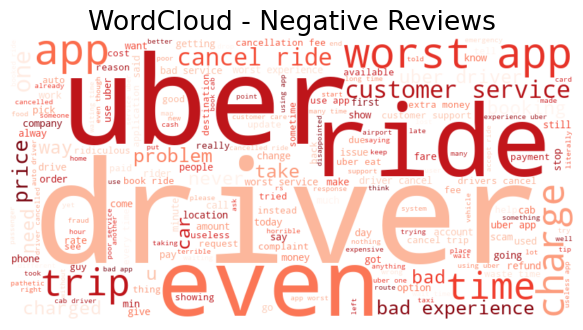

In [185]:
# Buat WordCloud untuk sentimen negatif
negative_text = " ".join(data[data['text_sentiment'] == 'Negative']['review6'].dropna())
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Negative Reviews')
plt.show()

> # Topik yang Paling Banyak Dikritik (negatif)

In [186]:
# Filter hanya review negatif
neg_reviews = data[data['text_sentiment'] == 'Negative']['review6'].dropna()

In [187]:
# Inisialisasi TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english', max_features=30)

In [188]:
# Fit dan transform
tfidf_matrix = tfidf.fit_transform(neg_reviews)

In [189]:
# Ambil hasil tf-idf jadi DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

In [190]:
# Hitung rata-rata skor tf-idf per kata
tfidf_mean = tfidf_df.mean().sort_values(ascending=False)
tfidf_mean.head(15)

app           0.145020
uber          0.133027
driver        0.098240
ride          0.094063
drivers       0.091287
worst         0.088056
bad           0.085047
service       0.079044
time          0.076907
cancel        0.053949
experience    0.048638
customer      0.046207
trip          0.042061
use           0.041359
money         0.040863
dtype: float64

C:\Users\rinda\AppData\Local\Temp\ipykernel_27052\476885621.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tfidf_mean.head(15).values, y=tfidf_mean.head(15).index, palette='Reds_r')


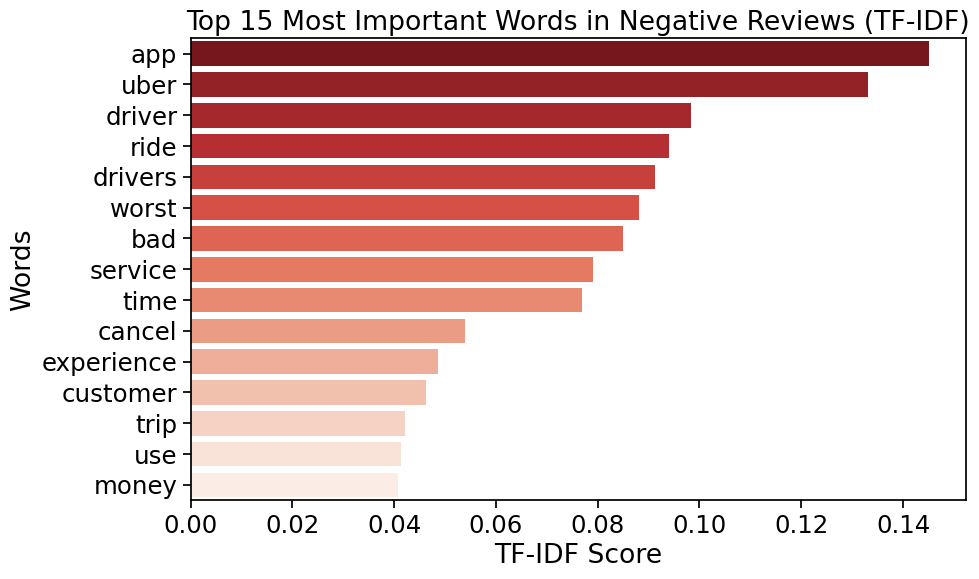

In [191]:
# Plot top 15 tf-idf words
plt.figure(figsize=(10,6))
sns.barplot(x=tfidf_mean.head(15).values, y=tfidf_mean.head(15).index, palette='Reds_r')
plt.title("Top 15 Most Important Words in Negative Reviews (TF-IDF)")
plt.xlabel("TF-IDF Score")
plt.ylabel("Words")
plt.show()

🔍 Insight dari TF-IDF Review Negatif (Topik Kritik Utama) :  
1. Masalah Teknologi & Aplikasi
    * `app`, `uber`, `use` menunjukkan keluhan tentang aplikasi Uber, mungkin error, bug, atau UX yang buruk.  
2. Kualitas Layanan Pengemudi
    * `driver`, `drivers`, `ride`, `trip` → banyak user menyorot pengalaman buruk dengan sopir, keterlambatan, attitude, atau perjalanan yang tidak memuaskan.  
3. Pengalaman Negatif yang Emosional
    * `worst`, `bad`, `cancel`, `experience` → kata sifat negatif ini menguatkan bahwa user benar-benar kecewa.
cancel kemungkinan terkait pembatalan sepihak oleh driver atau app.  
4. Masalah Pelayanan Pelanggan & Waktu
    * `service`, `customer`, `time` → user merasa respon support lambat, tidak membantu, atau tidak profesional.
time juga bisa menunjukkan keterlambatan, atau waktu tunggu yang tidak wajar.  
5. Keuangan
    * `money` muncul meskipun skornya lebih kecil → bisa jadi kritik terkait harga, refund yang tidak kunjung dikembalikan, atau biaya tambahan.harga, refund yang tidak kunjung dikembalikan, atau biaya tambahan.

> # Tren Sentimen dari Waktu ke Waktu

In [208]:
data.head(10)

,content,score,at,review1,review2,review3,review4,review5,review6,message_prep_stem,message_prep_lemma,sentiment,vader_compound,text_sentiment,month_year
0,everything has been done well!,5,2025-04-13 18:48:34,everything has been done well!,everything has been done well!,everything has been done well!,everything has been done well,everything has been done well,everything done well,everyth done well,everything done well,Positive,0.2732,Positive,2025-04
1,he was very helpful he assisted me with the kids and my bags,5,2025-04-13 18:47:12,he was very helpful he assisted me with the kids and my bags,he was very helpful he assisted me with the kids and my bags,he was very helpful he assisted me with the kids and my bags,he was very helpful he assisted me with the kids and my bags,he was very helpful he assisted me with the kids and my bags,helpful assisted kids bags,help assist kid bag,helpful assisted kid bag,Positive,0.4215,Positive,2025-04
2,"on time , driver is cool",5,2025-04-13 18:46:21,"on time , driver is cool","on time , driver is cool","on time , driver is cool",on time driver is cool,on time driver is cool,time driver cool,time driver cool,time driver cool,Positive,0.3182,Positive,2025-04
3,"Trip fare cahanged and increased by 40% when we reached at destination, Very bad idea of Uber to fool the customers.",1,2025-04-13 18:46:12,"trip fare cahanged and increased by 40% when we reached at destination, very bad idea of uber to fool the customers.","trip fare cahanged and increased by 40% when we reached at destination, very bad idea of uber to fool the customers.","trip fare cahanged and increased by % when we reached at destination, very bad idea of uber to fool the customers.",trip fare cahanged and increased by when we reached at destination very bad idea of uber to fool the customers,trip fare cahanged and increased by when we reached at destination very bad idea of uber to fool the customers,trip fare cahanged increased reached destination bad idea uber fool customers,trip fare cahang increas reach destin bad idea uber fool custom,trip fare cahanged increased reached destination bad idea uber fool customer,Negative,-0.6361,Negative,2025-04
4,good,5,2025-04-13 18:44:44,good,good,good,good,good,good,good,good,Positive,0.4404,Positive,2025-04
5,cheapest fare 👍,5,2025-04-13 18:42:56,cheapest fare 👍,cheapest fare 👍,cheapest fare 👍,cheapest fare 👍,cheapest fare 👍,cheapest fare 👍,cheapest fare 👍,cheapest fare 👍,Positive,0.0000,Neutral,2025-04
6,good app,5,2025-04-13 18:33:58,good app,good app,good app,good app,good app,good app,good app,good app,Positive,0.4404,Positive,2025-04
7,nice experience,5,2025-04-13 18:31:37,nice experience,nice experience,nice experience,nice experience,nice experience,nice experience,nice experi,nice experience,Positive,0.4215,Positive,2025-04
8,enjoyable drive,5,2025-04-13 18:27:56,enjoyable drive,enjoyable drive,enjoyable drive,enjoyable drive,enjoyable drive,enjoyable drive,enjoy drive,enjoyable drive,Positive,0.4404,Positive,2025-04
9,Good app,5,2025-04-13 18:26:47,good app,good app,good app,good app,good app,good app,good app,good app,Positive,0.4404,Positive,2025-04


Apakah ada lonjakan review negatif di bulan tertentu?

In [204]:
data['at'] = pd.to_datetime(data['at'])

C:\Users\rinda\AppData\Local\Temp\ipykernel_27052\2152089891.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['at'] = pd.to_datetime(data['at'])


In [205]:
data['month_year'] = data['at'].dt.to_period('M').astype(str)

C:\Users\rinda\AppData\Local\Temp\ipykernel_27052\2136212810.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['month_year'] = data['at'].dt.to_period('M').astype(str)


In [206]:
def get_sentiment(score):
    if score >= 4:
        return 'Positive'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Negative'

data['sentiment'] = data['score'].apply(get_sentiment)


C:\Users\rinda\AppData\Local\Temp\ipykernel_27052\2921016999.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['sentiment'] = data['score'].apply(get_sentiment)


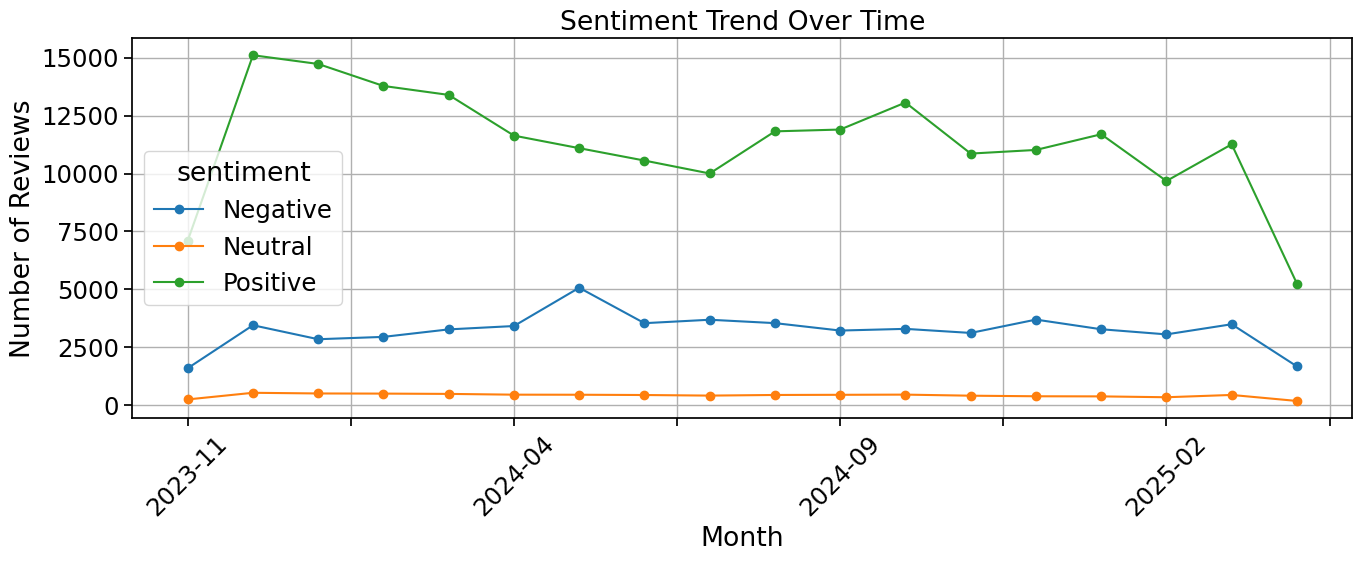

In [209]:
# Buat tabel tren sentimen
sentiment_trend = data.groupby(['month_year', 'sentiment']).size().unstack().fillna(0)
sentiment_trend.plot(kind='line', figsize=(14,6), marker='o')
plt.title('Sentiment Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**1. Dominasi Sentimen Positif**  
* Sentimen positif mendominasi sepanjang waktu.
* Angka tertinggi terjadi sekitar Desember 2023 – Januari 2024, dengan lebih dari 15.000 review positif.
* Ini bisa menunjukkan adanya:
    * Promosi besar-besaran,
    * Peningkatan layanan (misalnya fitur baru),
    * Atau musim liburan dengan pengalaman pengguna yang lebih baik.

**2. Tren Penurunan Sentimen Positif**  
* Setelah puncak awal tahun 2024, jumlah review positif terus menurun hingga Maret 2025.
* Di akhir periode (sekitar April 2025), review positif hanya tersisa sekitar 5.000-an.
* Ini bisa menandakan:
    * Penurunan kualitas layanan,
    * Masalah teknis atau operasional,
    * Atau berkurangnya engagement dari pengguna (mungkin karena pesaing?).

**3. Sentimen Negatif Cenderung Stabil Tapi Fluktuatif**  
* Mulai dari 1.500 review negatif di akhir 2023 → naik hingga 5.000 di pertengahan 2024 → turun lagi.
* Terjadi beberapa lonjakan negatif di:
    * Sekitar Mei 2024 → bisa jadi ada insiden spesifik (delay, bug, atau masalah harga),
    * Maret 2025 juga terlihat adanya kenaikan signifikan.
* Ini perlu ditelusuri lebih lanjut lewat data operasional/peristiwa terkait.



> # Up to Google BigQuery

In [217]:
from google.oauth2 import service_account
import pandas_gbq

project_id = 'ubersentiment-analysis'
dataset_id = 'Uber_Sentiment_Analysis'
table_name = 'Uber_Performance using NLP'
key_path = r"C:\Users\rinda\Documents\Purwadhika School\JCDS_2804_DATA SCIENCE\Modul 2_ARTICLE\ubersentiment-analysis-344dfb1ab721.json"

scopes = ['https://www.googleapis.com/auth/bigquery']
credentials = service_account.Credentials.from_service_account_file(key_path, scopes=scopes)

pandas_gbq.to_gbq(df, 
                  f'{dataset_id}.{table_name}',
                  project_id=project_id, 
                  if_exists='replace', 
                  credentials=credentials)

100%|██████████| 1/1 [00:00<?, ?it/s]
